# DS605 — Lab 4: Airbnb NYC Price Prediction
## Task 1 — Data Analysis & Preparation

This notebook covers:
1. Loading & initial inspection
2. Cleaning (invalid rows, missing values)
3. Outlier treatment
4. Feature engineering — review recency, host-based, availability-based, distance-based
5. Encoding categorical variables (leakage-safe)
6. Feature selection using SHAP


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 1. Load & Inspect Data

In [3]:
df = pd.read_csv('AB_NYC_2019.csv')
print(df.shape)
df.head()


(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## 2. Initial Cleaning

- Drop listings with `price == 0` (not a real nightly rate — data error, not a free stay).
- Drop irrelevant / non-generalizable identifier columns.
- Check for exact duplicate rows.


In [ ]:
print("Zero-price listings:", (df['price'] == 0).sum())
df = df[df['price'] > 0].copy()

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

df.shape


Zero-price listings: 11
Duplicate rows: 0


(48884, 16)

## 3. Missing Value Handling

- `reviews_per_month` missing == listing has never been reviewed → fill with **0** (this is the
  correct value, not an imputation guess).
- `last_review` missing == same reason. We do **not** fill this with a fake date — instead we
  engineer an explicit `has_reviews` flag and a sentinel value for recency (see Section 5).
- `name` / `host_name` missing → fill with a placeholder; these aren't used as direct numeric
  predictors so this just prevents downstream errors.


In [4]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['name'] = df['name'].fillna('')
df['host_name'] = df['host_name'].fillna('Unknown')

# keep last_review as-is (with NaT) for now — handled explicitly in feature engineering
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

df[['reviews_per_month', 'name', 'host_name', 'last_review']].isnull().sum()


,0
reviews_per_month,0
name,0
host_name,0
last_review,10052


## 4. Outlier Treatment

Two different, purpose-fit techniques are used depending on the variable:

- **`price`**: heavily right-skewed (mean 153 vs. max 10,000). Instead of deleting rows, we
  **winsorize at the 1st/99th percentile** (caps extreme values rather than discarding
  potentially valid but expensive listings), and separately apply a **log1p transform** for
  modeling — log-price is close to normal and regression models perform far better on it.
- **`minimum_nights`**: max of 1,250 is not realistic for nightly stays. We cap at a sensible
  business threshold (365 days) then winsorize the remainder at the 99th percentile, since a
  hard IQR cut here would remove valid medium/long-term stays.
- **`availability_365`**: already bounded [0, 365] by definition — no outlier treatment needed,
  just bucketing later (see Section 5).


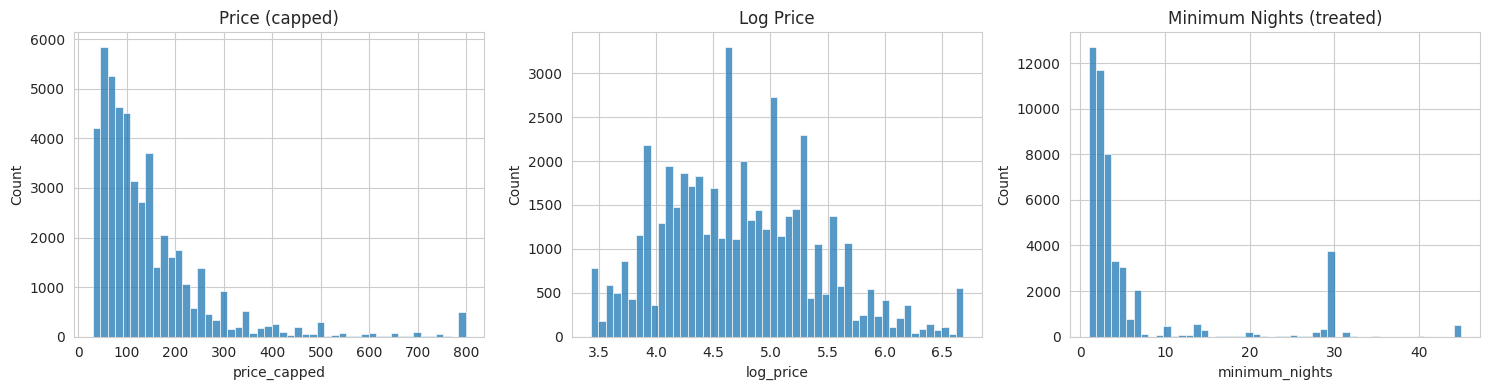

In [5]:
def winsorize(series, lower_q=0.01, upper_q=0.99):
    lo, hi = series.quantile([lower_q, upper_q])
    return series.clip(lo, hi)

# price: cap unrealistic extremes, then log-transform for modeling
df['price_capped'] = winsorize(df['price'], 0.01, 0.99)
df['log_price'] = np.log1p(df['price_capped'])

# minimum_nights: hard business cap at 365, then winsorize
df['minimum_nights'] = df['minimum_nights'].clip(upper=365)
df['minimum_nights'] = winsorize(df['minimum_nights'], 0.0, 0.99)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['price_capped'], bins=50, ax=axes[0]).set_title('Price (capped)')
sns.histplot(df['log_price'], bins=50, ax=axes[1]).set_title('Log Price')
sns.histplot(df['minimum_nights'], bins=50, ax=axes[2]).set_title('Minimum Nights (treated)')
plt.tight_layout()
plt.show()


## 5. Feature Engineering

### 5.1 Review-recency features

- `has_reviews`: binary flag — listing has ever been reviewed.
- `days_since_last_review`: computed as `reference_date - last_review`. For listings with
  **no** review, we do NOT fake a date — we use an explicit sentinel (max observed gap + 1),
  which lets tree-based models cleanly separate "never reviewed" from "reviewed long ago"
  rather than being told they're equally recent or equally stale.
- `review_density`: `number_of_reviews / days_since_last_review` proxy — separates listings
  that are old-but-dormant from active/popular ones.


In [6]:
reference_date = df['last_review'].max()  # most recent review date in the dataset

df['has_reviews'] = df['last_review'].notna().astype(int)
df['days_since_last_review'] = (reference_date - df['last_review']).dt.days

sentinel = df['days_since_last_review'].max() + 1
df['days_since_last_review'] = df['days_since_last_review'].fillna(sentinel)

# review_density: reviews per day since first activity signal (avoid div-by-zero)
df['review_density'] = df['number_of_reviews'] / (df['days_since_last_review'] + 1)

df[['has_reviews', 'days_since_last_review', 'review_density']].describe()


,has_reviews,days_since_last_review,review_density
count,48895.000000,48895.000000,48895.000000
mean,0.794417,841.883915,2.099664
std,0.404131,1170.256261,8.232188
min,0.000000,0.000000,0.000000
25%,1.000000,19.000000,0.001479
50%,1.000000,186.000000,0.040404
75%,1.000000,1201.000000,0.907192
max,1.000000,3025.000000,436.000000


### 5.2 Host-based features

- `is_multi_listing_host`: flag for hosts managing more than one listing (professional /
  property-management style hosts price differently than individuals renting a spare room).
- `host_listings_bucket`: bucketed version of `calculated_host_listings_count` to reduce the
  influence of a small number of hosts with very large portfolios.


In [7]:
df['is_multi_listing_host'] = (df['calculated_host_listings_count'] > 1).astype(int)

df['host_listings_bucket'] = pd.cut(
    df['calculated_host_listings_count'],
    bins=[0, 1, 2, 5, 10, np.inf],
    labels=['1', '2', '3-5', '6-10', '10+']
)

df[['is_multi_listing_host', 'host_listings_bucket']].value_counts()


is_multi_listing_host  host_listings_bucket
0                      1                       32303
1                      2                        6658
                       3-5                      5138
                       10+                      2967
                       6-10                     1829
Name: count, dtype: int64

### 5.3 Availability-based features

- `occupancy_proxy`: `365 - availability_365` — rough proxy for how booked-up a listing is.
- `availability_bucket`: categorizes into rarely / moderately / highly available, since 0
  availability is very common (25th percentile) and likely means "inactive" rather than
  "fully booked solid."


In [8]:
df['occupancy_proxy'] = 365 - df['availability_365']

df['availability_bucket'] = pd.cut(
    df['availability_365'],
    bins=[-1, 0, 90, 270, 365],
    labels=['none', 'low', 'medium', 'high']
)

df[['occupancy_proxy', 'availability_bucket']].describe(include='all')


,occupancy_proxy,availability_bucket
count,48895.000000,48895
unique,NaN,4
top,NaN,none
freq,NaN,17533
mean,252.218673,NaN
std,131.622289,NaN
min,0.000000,NaN
25%,138.000000,NaN
50%,320.000000,NaN
75%,365.000000,NaN


### 5.4 Distance-based location features

Raw `latitude`/`longitude` aren't directly meaningful to most models as linear predictors.
Location value is better captured by **distance from key landmarks**:

- `distance_to_center` — distance to Times Square (proxy for tourism/central desirability).
- `distance_to_jfk` — distance to JFK Airport (proxy for transit convenience).

Both computed with the **Haversine formula** (great-circle distance on a sphere), which is the
correct choice for lat/long coordinates — Euclidean distance on raw degrees distorts distance
because degrees of longitude shrink as latitude increases.


In [9]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/long points."""
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

TIMES_SQUARE = (40.7580, -73.9855)
JFK_AIRPORT = (40.6413, -73.7781)

df['distance_to_center'] = haversine_distance(
    df['latitude'], df['longitude'], *TIMES_SQUARE
)
df['distance_to_jfk'] = haversine_distance(
    df['latitude'], df['longitude'], *JFK_AIRPORT
)

df[['distance_to_center', 'distance_to_jfk']].describe()


,distance_to_center,distance_to_jfk
count,48895.000000,48895.000000
mean,7.107648,18.534076
std,4.437340,4.339055
min,0.068492,1.974654
25%,3.819186,15.545116
50%,6.390499,18.854535
75%,9.417947,21.630605
max,35.898255,42.133462


### 5.5 Additional supporting features

- `minimum_nights_bucket`: short/medium/long-term stay bucket — reduces outlier sensitivity
  and captures that long-term rentals price very differently per night.
- `room_type_neighbourhood`: interaction term between `room_type` and `neighbourhood_group`,
  since e.g. "Entire home in Manhattan" behaves very differently from "Shared room in Bronx."
- `name_length`: simple text-derived feature from the listing title (very cheap, often
  weakly predictive of "effort put into listing").


In [10]:
df['minimum_nights_bucket'] = pd.cut(
    df['minimum_nights'],
    bins=[0, 3, 14, np.inf],
    labels=['short', 'medium', 'long']
)

df['room_type_neighbourhood'] = df['room_type'] + '_' + df['neighbourhood_group']
df['name_length'] = df['name'].str.len()

df[['minimum_nights_bucket', 'room_type_neighbourhood', 'name_length']].head()


,minimum_nights_bucket,room_type_neighbourhood,name_length
0,short,Private room_Brooklyn,34
1,short,Entire home/apt_Manhattan,21
2,short,Private room_Manhattan,35
3,short,Entire home/apt_Brooklyn,31
4,medium,Entire home/apt_Manhattan,48


## 6. Train/Test Split

Split **before** any target-dependent encoding (e.g. mean price per neighbourhood) to avoid
data leakage — the encoder must only ever see training data.


In [11]:
feature_cols_raw = [
    'room_type', 'neighbourhood_group', 'neighbourhood', 'room_type_neighbourhood',
    'latitude', 'longitude', 'distance_to_center', 'distance_to_jfk',
    'minimum_nights', 'minimum_nights_bucket',
    'number_of_reviews', 'reviews_per_month', 'has_reviews',
    'days_since_last_review', 'review_density',
    'calculated_host_listings_count', 'is_multi_listing_host', 'host_listings_bucket',
    'availability_365', 'occupancy_proxy', 'availability_bucket',
    'name_length',
]
target_col = 'log_price'

X = df[feature_cols_raw].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape


((39116, 22), (9779, 22))

## 7. Encoding Categorical Variables

- **Low cardinality** (`room_type`, `neighbourhood_group`, `availability_bucket`,
  `minimum_nights_bucket`, `host_listings_bucket`, `room_type_neighbourhood`): one-hot encoded.
- **High cardinality** (`neighbourhood`, 221 unique values): one-hot would over-inflate
  dimensionality and create very sparse columns. Instead we use **mean-price target encoding**,
  fit **only on the training set**, with smoothing toward the global mean for rare/unseen
  categories to reduce overfitting.


In [12]:
def target_encode(train_series, train_target, test_series, global_mean, m=20):
    """Smoothed mean target encoding: blends per-category mean with global mean,
    weighted by category frequency (m = smoothing strength)."""
    stats = train_target.groupby(train_series).agg(['mean', 'count'])
    smoothed = (stats['mean'] * stats['count'] + global_mean * m) / (stats['count'] + m)
    train_encoded = train_series.map(smoothed).fillna(global_mean)
    test_encoded = test_series.map(smoothed).fillna(global_mean)
    return train_encoded, test_encoded

global_mean_price = y_train.mean()
X_train['neighbourhood_te'], X_test['neighbourhood_te'] = target_encode(
    X_train['neighbourhood'], y_train, X_test['neighbourhood'], global_mean_price
)
X_train = X_train.drop(columns=['neighbourhood'])
X_test = X_test.drop(columns=['neighbourhood'])

low_card_cols = [
    'room_type', 'neighbourhood_group', 'availability_bucket',
    'minimum_nights_bucket', 'host_listings_bucket', 'room_type_neighbourhood'
]
X_train = pd.get_dummies(X_train, columns=low_card_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=low_card_cols, drop_first=True)

# align columns (test may be missing a rare dummy category)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train.shape, X_test.shape


((39116, 45), (9779, 45))

## 8. Feature Selection with SHAP

Rather than relying on raw correlation (misleading for non-linear effects like the
neighbourhood/location encodings), we fit a quick tree-based model and use **SHAP values** to
rank true feature importance — how much each feature actually moves predictions, on average,
across the dataset.


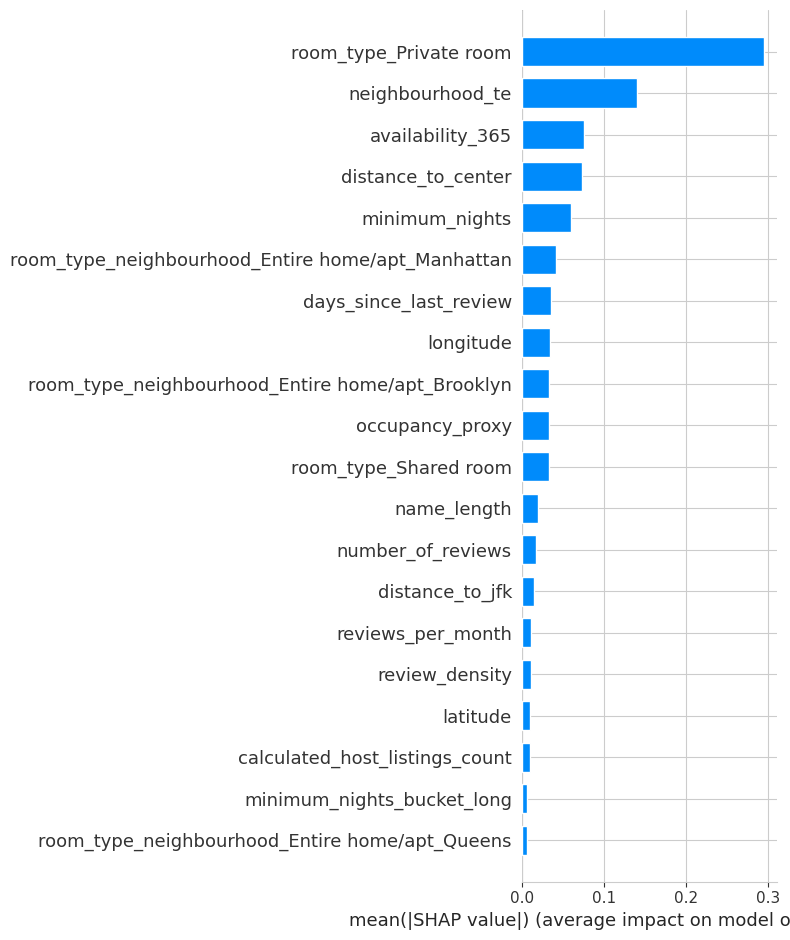

In [13]:
import xgboost as xgb
import shap

fs_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1
)
fs_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(fs_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()


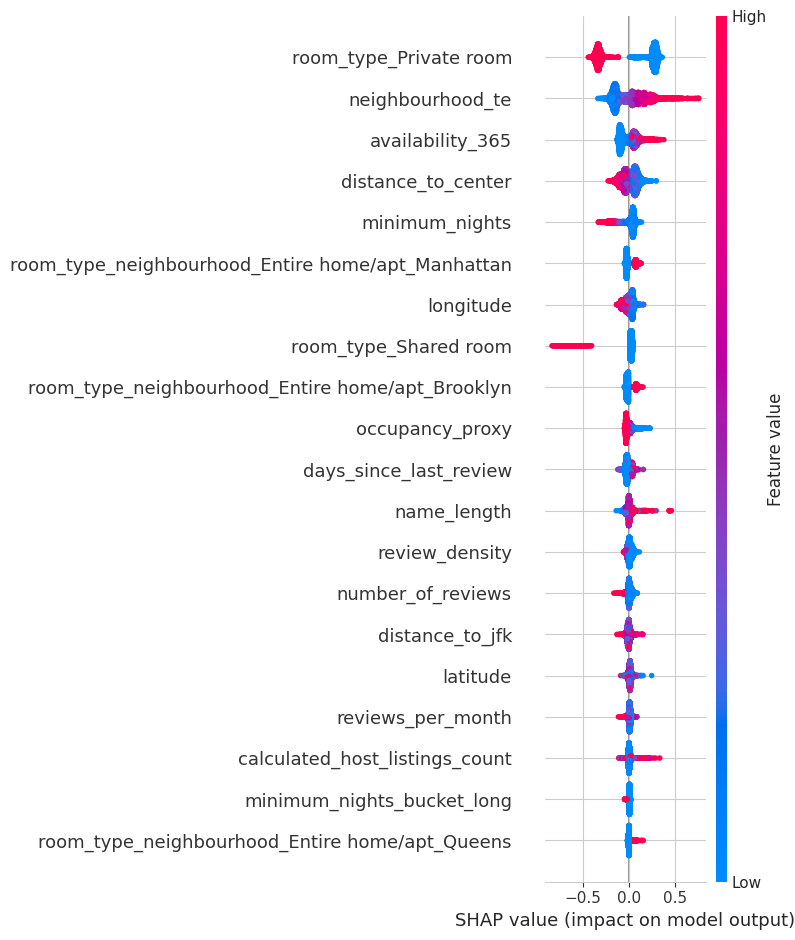

In [ ]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()


In [14]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)

print("Top 20 features by mean |SHAP value|:")
mean_abs_shap.head(20)


Top 20 features by mean |SHAP value|:


,0
room_type_Private room,0.295682
neighbourhood_te,0.139841
availability_365,0.076213
distance_to_center,0.073817
minimum_nights,0.060104
room_type_neighbourhood_Entire home/apt_Manhattan,0.041295
days_since_last_review,0.035065
longitude,0.034767
room_type_neighbourhood_Entire home/apt_Brooklyn,0.033806
occupancy_proxy,0.032852


**Selecting the final feature set:** keep features whose mean |SHAP value| clears a small
threshold (e.g. top ~25, or anything above 1% of the top feature's importance) — this drops
near-zero-signal features (e.g. rare one-hot dummies) while keeping everything with real
predictive contribution, feeding into Task 2 (model training).


In [15]:
SHAP_THRESHOLD = mean_abs_shap.iloc[0] * 0.01  # 1% of top feature's importance
selected_features = mean_abs_shap[mean_abs_shap > SHAP_THRESHOLD].index.tolist()

print(f"Selected {len(selected_features)} / {X_train.shape[1]} features")
print(selected_features)

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]


Selected 23 / 45 features
['room_type_Private room', 'neighbourhood_te', 'availability_365', 'distance_to_center', 'minimum_nights', 'room_type_neighbourhood_Entire home/apt_Manhattan', 'days_since_last_review', 'longitude', 'room_type_neighbourhood_Entire home/apt_Brooklyn', 'occupancy_proxy', 'room_type_Shared room', 'name_length', 'number_of_reviews', 'distance_to_jfk', 'reviews_per_month', 'review_density', 'latitude', 'calculated_host_listings_count', 'minimum_nights_bucket_long', 'room_type_neighbourhood_Entire home/apt_Queens', 'neighbourhood_group_Manhattan', 'availability_bucket_low', 'room_type_neighbourhood_Private room_Manhattan']


## 9. Save Processed Data

Persist the cleaned/engineered train-test split so Task 2 (model training) can load it directly
without repeating this pipeline.


In [16]:
import joblib

X_train_selected.to_csv('X_train.csv', index=False)
X_test_selected.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

joblib.dump(selected_features, 'selected_features.pkl')
joblib.dump({'global_mean_price': global_mean_price}, 'encoding_artifacts.pkl')

print("Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv, selected_features.pkl, encoding_artifacts.pkl")


Saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv, selected_features.pkl, encoding_artifacts.pkl


In [17]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()   # log_price
y_test = pd.read_csv('y_test.csv').squeeze()

print(X_train.shape, X_test.shape)

(39116, 23) (9779, 23)


In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold
import xgboost as xgb

RANDOM_STATE = 42
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=RANDOM_STATE, n_jobs=-1),
}

scoring = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'}
results = []

for name, model in models.items():
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)
    results.append({
        'model': name,
        'cv_rmse': -cv_res['test_rmse'].mean(),
        'cv_mae': -cv_res['test_mae'].mean(),
        'cv_r2': cv_res['test_r2'].mean(),
        'train_rmse': -cv_res['train_rmse'].mean(),   # for overfitting check
    })

results_df = pd.DataFrame(results).sort_values('cv_rmse')
results_df

,model,cv_rmse,cv_mae,cv_r2,train_rmse
4,XGBoost,0.403831,0.298806,0.636171,0.355406
3,RandomForest,0.408114,0.300713,0.628396,0.271331
0,LinearRegression,0.433358,0.324004,0.581023,0.432962
1,Ridge,0.433360,0.324008,0.581019,0.432995
2,Lasso,0.433597,0.324196,0.580562,0.433316


In [19]:
from sklearn.model_selection import RandomizedSearchCV, KFold

cv_search = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 3-fold for search speed

param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
}

xgb_base = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, tree_method='hist')

search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=15,
    scoring='neg_root_mean_squared_error', cv=cv_search,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

best_model = search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE: 0.4045384561814848


Train RMSE: 0.3418 | Test RMSE: 0.3889 | Gap: 0.0471


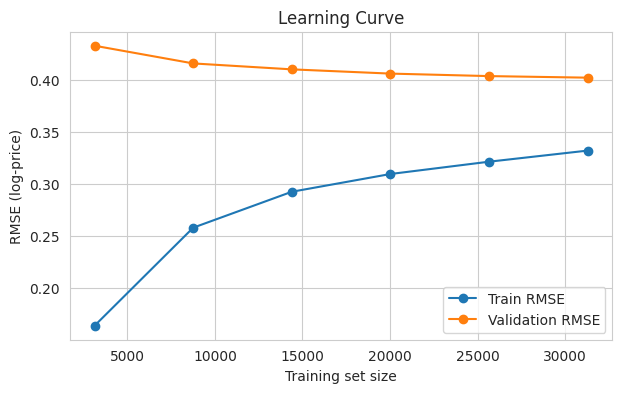

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Gap: {test_rmse - train_rmse:.4f}")

# Learning curve to visualize the gap across training set sizes
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=cv,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, -train_scores.mean(axis=1), 'o-', label='Train RMSE')
plt.plot(train_sizes, -val_scores.mean(axis=1), 'o-', label='Validation RMSE')
plt.xlabel('Training set size')
plt.ylabel('RMSE (log-price)')
plt.title('Learning Curve')
plt.legend()
plt.show()

Final Test RMSE: $86.95
Final Test MAE:  $45.26
Final Test R²:   0.4678


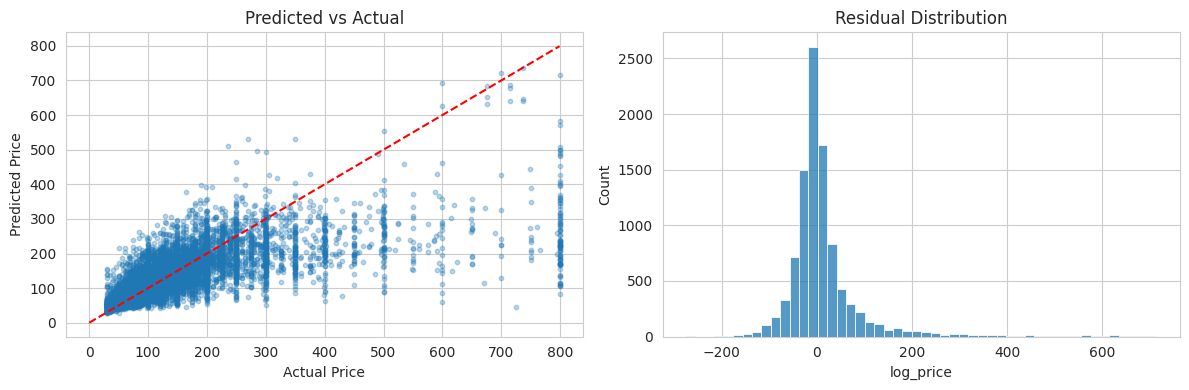

In [21]:
# back-transform from log-price to real price for interpretability
y_test_price = np.expm1(y_test)
test_pred_price = np.expm1(test_pred)

final_rmse = np.sqrt(mean_squared_error(y_test_price, test_pred_price))
final_mae = mean_absolute_error(y_test_price, test_pred_price)
final_r2 = r2_score(y_test_price, test_pred_price)

print(f"Final Test RMSE: ${final_rmse:.2f}")
print(f"Final Test MAE:  ${final_mae:.2f}")
print(f"Final Test R²:   {final_r2:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_test_price, test_pred_price, alpha=0.3, s=10)
ax[0].plot([0, y_test_price.max()], [0, y_test_price.max()], 'r--')
ax[0].set_xlabel('Actual Price'); ax[0].set_ylabel('Predicted Price')
ax[0].set_title('Predicted vs Actual')

residuals = y_test_price - test_pred_price
sns.histplot(residuals, bins=50, ax=ax[1])
ax[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

In [22]:
selected_features = joblib.load('selected_features.pkl')
encoding_artifacts = joblib.load('encoding_artifacts.pkl')

pipeline_bundle = {
    'model': best_model,
    'selected_features': selected_features,
    'encoding_artifacts': encoding_artifacts,   # e.g. neighbourhood target-encoding map, global_mean_price
    'target_transform': 'log1p',                # so Task 3's app knows to expm1() the prediction
}

joblib.dump(pipeline_bundle, 'final_model_pipeline.pkl')
print("Saved final_model_pipeline.pkl")

Saved final_model_pipeline.pkl
